A script to compute the zonal wavenumber of the Lamb wave in a numerical simulation.
Use this to examine the regime we are in, relative to the wavenumbers of acoustic and gravity waves

In [6]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import xarray as xr
import matplotlib.colors as colors
import metpy
import cmaps
import matplotlib
from functions import *

In [7]:
# Choose the dynamical core and the horizontal resolution

#dycore = 'SE'
dycore = 'FV3'
#dycore = 'MPAS'

#res = 'one_deg'
#res = 'half_deg'
res = 'quarter_deg'

if dycore == 'SE':
    run_base = '/glade/derecho/scratch/nforcone/'
    if res == 'one_deg':
        #case = 'CAM_6_4_089_ne30_ne30_mg16_L25_ztop12.5km_dz500m_pressure_perturb'
        #case = 'CAM_6_4_089_ne30_ne30_mg16_L50_ztop25km_dz500m_pressure_perturb'
        #case = 'CAM_6_4_089_ne30_ne30_mg16_L100_ztop50km_dz500m_pressure_perturb'
        #case = 'CAM_6_4_089_ne30_ne30_mg16_L200_ztop100km_dz500m_pressure_perturb'

        # Temperature studies:
        #case = 'CAM_6_4_089_ne30_ne30_mg16_L100_ztop50km_dz500m_pressure_perturb_250K'
        #case = 'CAM_6_4_089_ne30_ne30_mg16_L100_ztop50km_dz500m_pressure_perturb_300K'
        case = 'CAM_6_4_089_ne30_ne30_mg16_L100_ztop50km_dz500m_pressure_perturb_325K'
    elif res == 'half_deg':
        case = 'yo'
    elif res == 'quarter_deg':
        case = 'yo'
    nc_file = case + '.cam.h0i.0001-01-01-00000.nc'
elif dycore == 'FV3':
    run_base = "/glade/derecho/scratch/timand/"
    if res == 'one_deg':
        case = 'cam_6_4_095_lamb_fv3_C96_ztop_12.5km_dt_1min'
        #case = 'cam_6_4_095_lamb_fv3_C96_ztop_25km_dt_1min'
        #case = 'cam_6_4_095_lamb_fv3_C96_ztop_50km_dt_1min'
        #case = 'cam_6_4_095_lamb_fv3_C96_ztop_100km_dt_1min'
        nc_file = case + '.cam.h0i.0001-01-01-00000_p_pert_no_sponge.regrid.1x1.nc'
    elif res == 'half_deg':
        case = 'cam_6_4_095_lamb_fv3_C192_ztop_50km_dt_1min'
        nc_file = case + '.cam.h0i.0001-01-01-00000_p_pert_no_sponge.regrid.0.5x0.5.nc'
    elif res == 'quarter_deg':
        case = 'cam_6_4_095_lamb_fv3_C384_ztop_50km_dt_1min'
        nc_file = case + '.cam.h0i.0001-01-01-00000_p_pert.regrid.0.25x0.25.nc'
elif dycore == 'MPAS':
    run_base = '/glade/derecho/scratch/cjablono/'  

    if res == 'one_deg':
        ### MPAS 120 ### all cases but 50 km model top
        case = 'cam_6_4_161.MPAS120.L25.top_12.5km.fadiab.pressure_perturb'
        #case = 'cam_6_4_161.MPAS120.L50.top_25km.fadiab.pressure_perturb'
        #case = 'cam_6_4_161.MPAS120.L200.top_100km.fadiab.pressure_perturb'
        nc_file = case + '.cam.h0i.0001-01-01-00000.1min.regrid.1x1.18h.nc'

        # Different names for 50 km model top;
        #case = 'cam_6_4_161.MPAS120.L100.top_50km.fadiab.pressure_perturb'
        #nc_file = case + '.cam.h0i.0001-01-01-00000.1min.regrid.1x1.18h.epssm_0.1.cpair_default.50hPa.nc'
        #nc_file = case + '.cam.h0i.0001-01-01-00000.1min.regrid.1x1.18h.no_diffusion.cpair_default.50hPa.nc'
        #nc_file = case + '.cam.h0i.0001-01-01-00000.1min.regrid.1x1.18h.no_diffusion.smdiv_0.001.cpair_default.50hPa.nc'
    elif res == 'half_deg':
        case = 'cam_6_4_161.MPAS60.L100.top_50km.fadiab.pressure_perturb'
        #nc_file = case + '.cam.h0i.0001-01-01-00000.1min.regrid.0.5x0.5.18h.epssm_0.1.cpair_default.50hPa.nc'
        nc_file = case + '.cam.h0i.0001-01-01-00000.1min.regrid.0.5x0.5.18h.no_diffusion.cpair_default.50hPa.nc'
    elif res == 'quarter_deg':
        case = 'cam_6_4_161.MPAS30.L50.top_25km.fadiab.pressure_perturb'
        nc_file = case + '.cam.h0i.0001-01-01-00000.1min.regrid.0.25x0.25.18h.epssm_0.1.cpair_default.50hPa.nc'
        #nc_file = case + '.cam.h0i.0001-01-01-00000.1min.regrid.0.25x0.25.18h.no_diffusion.cpair_default.50hPa.nc'

# For all runs:
run_path = run_base + case + '/run/' + nc_file
nc = Dataset(run_path, 'r')

In [8]:
time = nc['time'][:]
lat_deg = nc['lat'][:]
lon_deg = nc['lon'][:]

# Work in radians
lat = lat_deg*np.pi/180
lon = lon_deg*np.pi/180

LON, LAT = np.meshgrid(lon_deg, lat_deg)

print(np.min(lon))
print(np.max(lon))
print(np.min(lat))
print(np.max(lat))

0.002181661564992912
6.281003645614593
-1.5686146652299038
1.5686146652299038


In [9]:
field_name = 'PS'
p0 = 1e5
R = 6371220

In [14]:
# Compute the wave speed! Here use PS
base_lat_ind = 90
base_lon_inds = np.array([120, 140, 160, 180, 200, 220, 240])

# Choose indices based on horizontal resolution:
if res == 'one_deg':
    lon_inds = base_lon_inds
    lat_ind = base_lat_ind
elif res == 'half_deg':
    lon_inds = base_lon_inds*2
    lat_ind = base_lat_ind*2 
elif res == 'quarter_deg':
    lon_inds = base_lon_inds*4 
    lat_ind = base_lat_ind*4


# Hmmm, is there an issue when regridding to 0.25x0.25??? The 0.125 offset is not desirable.

# Using the trailing zero crossing. This is less accurate, as is more sensitive to numerical dispersion error
#lamb_times, lamb_speed = lamb_wave_by_zero_crossing_ps(nc[field_name][:, lat_ind, :] - p0, time, lon_deg, lon_inds)

# Maximum method:
lamb_times, lamb_speed = find_lamb_wave(nc[field_name][:, lat_ind, :] - p0, time, lon_deg, lon_inds)
#lamb_times /= (24*60)
#lamb_speed *= 24*60

print(lon_deg[lon_inds])
print(lamb_speed)

[120.125 140.125 160.125 180.125 200.125 220.125 240.125]
327.39871085562055


Text(0.5, 0, 'Time (minutes)')

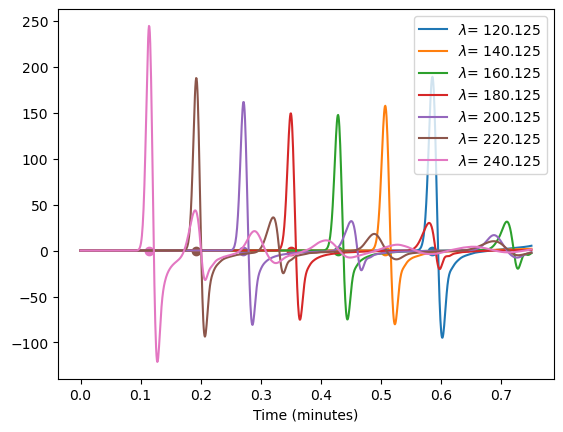

In [11]:
# Plot time series of the chosen points


plt.figure()
for i in np.arange(len(lon_inds)):
    plt.plot(time, nc[field_name][:, lat_ind, lon_inds[i]]-p0, label=r'$\lambda $= ' f'{lon_deg[lon_inds[i]]}')
    plt.scatter(lamb_times[i], 0)
plt.legend()

plt.xlabel('Time (minutes)')

In [12]:
# Make a Hovmuller that shows these points
cmap = plt.colormaps['PiYG']
conts = np.linspace(-10,10,11)

X, T = np.meshgrid(lon_deg, time)

plt.figure()
plot1 = plt.contourf(X, T, field[:, lat_ind, :], levels=conts, extend='both', cmap=cmap)
#plt.pcolormesh(X, T, field[:, lat_ind, :])
plt.scatter(lon_deg[lon_inds], lamb_times, c='k')
plt.xlim([90,270])
plt.colorbar(plot1)

plt.title(f'{dycore}')

NameError: name 'field' is not defined

<Figure size 640x480 with 0 Axes>